# 01 — Khám phá Dữ liệu (EDA)

**Đồ án 1 — ISV301002 | VNU International School**

Notebook này:
1. Load và kiểm tra dataset
2. Phân tích phân phối nhãn
3. Phân tích độ dài URL
4. Kiểm tra 15 features tĩnh
5. Vẽ correlation heatmap

**Dataset:** Malicious URLS Dataset

# 1. Load Dataset

Mục tiêu:
- Kiểm tra cấu trúc dataset
- Xác định số lượng mẫu
- Kiểm tra nhãn
- Kiểm tra missing values

In [35]:
# =========================================================
# 1. IMPORT THƯ VIỆN
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from urllib.parse import urlparse

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [37]:
# Đọc dataset
df = pd.read_csv("../data_src_notebooks/raw/malicious_phish.csv")
df.head(10)

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign
8,http://www.pashminaonline.com/pure-pashminas,defacement
9,allmusic.com/album/crazy-from-the-heat-r16990,benign


In [38]:
# =========================================================
# 3. KIỂM TRA TỔNG QUAN DATASET
# =========================================================

print("="*60)
print("THÔNG TIN DATASET")
print("="*60)

print("\nKích thước dataset:")
print(df.shape)

print("\nTên các cột:")
print(df.columns)

print("\n5 dòng đầu tiên:")
display(df.head())

THÔNG TIN DATASET

Kích thước dataset:
(651191, 2)

Tên các cột:
Index(['url', 'type'], dtype='object')

5 dòng đầu tiên:


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [ ]:
# =========================================================
# 4. KIỂM TRA KIỂU DỮ LIỆU
# =========================================================

print(df.dtypes)
# =========================================================
# 5. KIỂM TRA GIÁ TRỊ THIẾU
# =========================================================

print("="*60)
print("KIỂM TRA GIÁ TRỊ THIẾU")
print("="*60)

print(df.isnull().sum())
# =========================================================
# 6. XÓA GIÁ TRỊ THIẾU
# =========================================================

df = df.dropna()

print("Kích thước dataset sau khi xóa missing values:")
print(df.shape)
# =========================================================
# 7. PHÂN PHỐI NHÃN GỐC
# =========================================================

print(df['type'].value_counts())



url     object
type    object
dtype: object


In [41]:
# =========================================================
# 4. KIỂM TRA KIỂU DỮ LIỆU
# =========================================================

print(df.dtypes)
# =========================================================
# 5. KIỂM TRA GIÁ TRỊ THIẾU
# =========================================================

print("="*60)
print("KIỂM TRA GIÁ TRỊ THIẾU")
print("="*60)

print(df.isnull().sum())
# =========================================================
# 6. XÓA GIÁ TRỊ THIẾU
# =========================================================

df = df.dropna()

print("Kích thước dataset sau khi xóa missing values:")
print(df.shape)


url     object
type    object
dtype: object
KIỂM TRA GIÁ TRỊ THIẾU
url     0
type    0
dtype: int64
Kích thước dataset sau khi xóa missing values:
(651191, 2)


In [42]:
# =========================================================
# 7. PHÂN PHỐI NHÃN GỐC
# =========================================================

print(df['type'].value_counts())

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


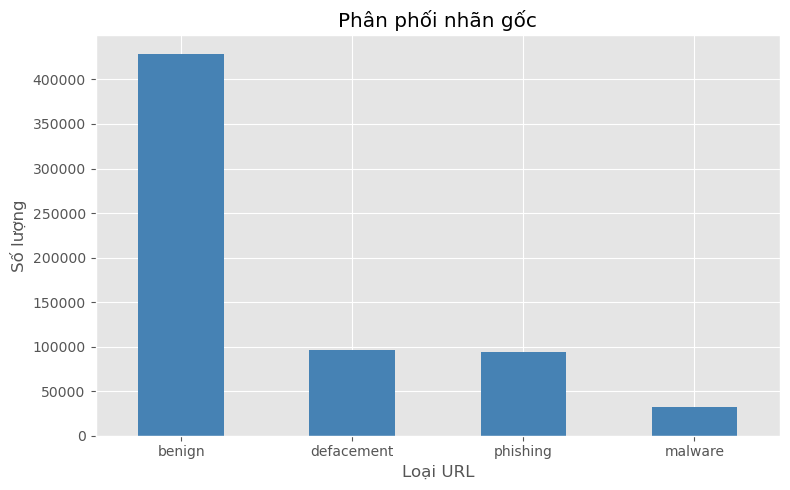

In [43]:
# =========================================================
# 8. VẼ BIỂU ĐỒ PHÂN PHỐI NHÃN GỐC
# =========================================================

fig, ax = plt.subplots(figsize=(8, 5))

df['type'].value_counts().plot(
    kind='bar',
    color='steelblue',
    ax=ax
)

ax.set_title('Phân phối nhãn gốc')
ax.set_xlabel('Loại URL')
ax.set_ylabel('Số lượng')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# =========================================================
# 9. CHUYỂN THÀNH BINARY CLASSIFICATION
# benign = 0
# phishing/malware/defacement = 1
# =========================================================

df['label'] = df['type'].apply(
    lambda x: 0 if x == 'benign' else 1
)

display(df[['type', 'label']].head())

,type,label
0,phishing,1
1,benign,0
2,benign,0
3,defacement,1
4,defacement,1


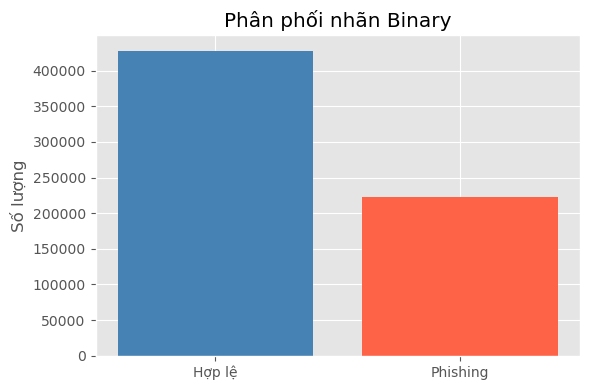

In [45]:
# =========================================================
# 11. VẼ BIỂU ĐỒ NHÃN BINARY
# =========================================================

label_counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ['Hợp lệ', 'Phishing'],
    label_counts.values,
    color=['steelblue', 'tomato']
)

ax.set_title('Phân phối nhãn Binary')
ax.set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

In [46]:
# =========================================================
# 12. TỶ LỆ MẤT CÂN BẰNG DỮ LIỆU
# =========================================================

ratio = label_counts[1] / label_counts[0]

print(f"Tỷ lệ phishing / hợp lệ: {ratio:.2f}")

Tỷ lệ phishing / hợp lệ: 0.52


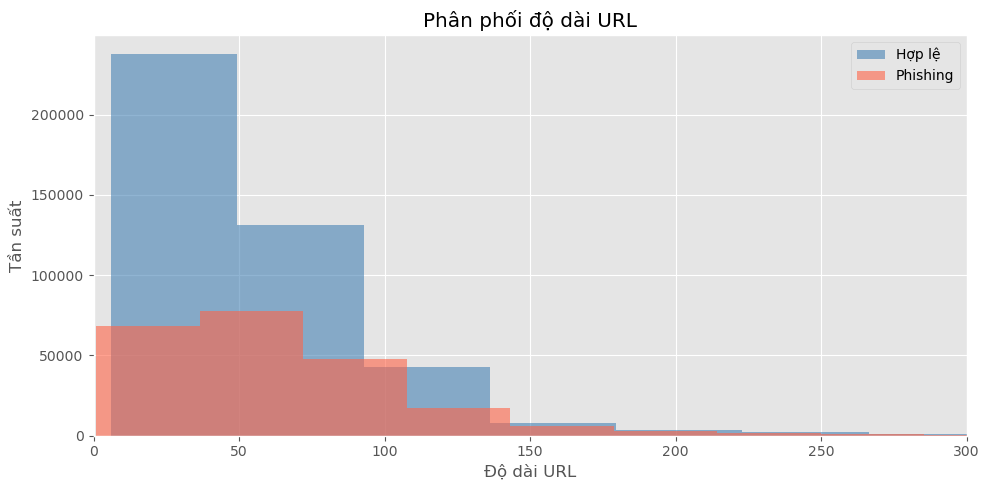

THỐNG KÊ ĐỘ DÀI URL
URL hợp lệ trung bình : 57.68
URL phishing trung bình : 64.92


In [47]:
# =========================================================
# 13. PHÂN TÍCH ĐỘ DÀI URL
# =========================================================

# Tạo feature độ dài URL
df['url_len'] = df['url'].str.len()

# Tách dữ liệu
legit_urls = df[df.label == 0]['url_len']
phishing_urls = df[df.label == 1]['url_len']

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

legit_urls.hist(
    bins=50,
    alpha=0.6,
    label='Hợp lệ',
    color='steelblue',
    ax=ax
)

phishing_urls.hist(
    bins=50,
    alpha=0.6,
    label='Phishing',
    color='tomato',
    ax=ax
)

ax.set_xlabel('Độ dài URL')
ax.set_ylabel('Tần suất')

ax.set_title('Phân phối độ dài URL')

ax.legend()

ax.set_xlim(0, 300)

plt.tight_layout()
plt.show()

# Thống kê
print("="*50)
print("THỐNG KÊ ĐỘ DÀI URL")
print("="*50)

print(f"URL hợp lệ trung bình : {legit_urls.mean():.2f}")

print(f"URL phishing trung bình : {phishing_urls.mean():.2f}")

In [48]:
# =========================================================
# 14. TẠO HÀM TRÍCH XUẤT 15 FEATURES
# =========================================================

FEATURE_NAMES = [
    'url_len',
    'domain_length',
    'num_digits',
    'num_special_chars',
    'num_hyphens',
    'num_dots',
    'num_subdomains',
    'has_https',
    'has_ip',
    'suspicious_count',
    'has_at',
    'double_slash',
    'tld_length',
    'path_length',
    'query_length'
]

suspicious_words = [
    'login',
    'verify',
    'secure',
    'account',
    'update',
    'banking',
    'confirm',
    'paypal',
    'password'
]


def extract_features(url):

    parsed = urlparse(url)

    features = []

    # 1. Độ dài URL
    features.append(len(url))

    # 2. Độ dài domain
    features.append(len(parsed.netloc))

    # 3. Số lượng chữ số
    features.append(
        sum(c.isdigit() for c in url)
    )

    # 4. Số ký tự đặc biệt
    features.append(
        len(re.findall(r'[^a-zA-Z0-9]', url))
    )

    # 5. Số dấu gạch ngang
    features.append(url.count('-'))

    # 6. Số dấu chấm
    features.append(url.count('.'))

    # 7. Số subdomain
    features.append(parsed.netloc.count('.'))

    # 8. Có HTTPS hay không
    features.append(
        1 if parsed.scheme == 'https' else 0
    )

    # 9. Có IP address hay không
    features.append(
        1 if re.match(
            r'^\d+\.\d+\.\d+\.\d+$',
            parsed.netloc
        ) else 0
    )

    # 10. Số suspicious words
    features.append(
        sum(word in url.lower()
            for word in suspicious_words)
    )

    # 11. Có ký tự @ hay không
    features.append(
        1 if '@' in url else 0
    )

    # 12. Có dấu // bất thường hay không
    features.append(
        1 if '//' in url[8:] else 0
    )

    # 13. Độ dài TLD
    tld = (
        parsed.netloc.split('.')[-1]
        if '.' in parsed.netloc
        else ''
    )

    features.append(len(tld))

    # 14. Độ dài path
    features.append(len(parsed.path))

    # 15. Độ dài query
    features.append(len(parsed.query))

    return features


def extract_batch(urls):

    return np.array([
        extract_features(url)
        for url in urls
    ])

In [49]:
# =========================================================
# 15. TRÍCH XUẤT FEATURES
# =========================================================

print("Đang trích xuất features...")
print("Quá trình này có thể mất vài giây.")

X_feat = extract_batch(df['url'].tolist())

feat_df = pd.DataFrame(
    X_feat,
    columns=FEATURE_NAMES
)

feat_df['label'] = df['label'].values

display(feat_df.head())

Đang trích xuất features...
Quá trình này có thể mất vài giây.


,url_len,domain_length,num_digits,num_special_chars,num_hyphens,num_dots,num_subdomains,has_https,has_ip,suspicious_count,has_at,double_slash,tld_length,path_length,query_length,label
0,16,0,0,3,1,2,0,0,0,0,0,0,0,16,0,1
1,35,0,1,5,0,2,0,0,0,0,0,0,0,35,0,0
2,31,0,1,5,0,2,0,0,0,0,0,0,0,31,0,0
3,88,21,7,18,1,3,2,0,0,0,0,0,2,10,49,1
4,235,23,22,14,1,2,1,0,0,0,0,0,3,10,194,1


In [50]:
# =========================================================
# 17. THỐNG KÊ THEO NHÃN
# =========================================================

group_stats = feat_df.groupby('label').mean().T

group_stats.columns = [
    'Hợp lệ',
    'Phishing'
]

display(group_stats)

,Hợp lệ,Phishing
url_len,57.675429,64.918611
domain_length,0.975578,12.790208
num_digits,5.607714,5.372839
num_special_chars,8.501298,11.122745
num_hyphens,1.838616,0.997378
num_dots,1.938421,2.688692
num_subdomains,0.090726,1.331479
has_https,0.004555,0.061545
has_ip,0.000000,0.032212
suspicious_count,0.086246,0.057977


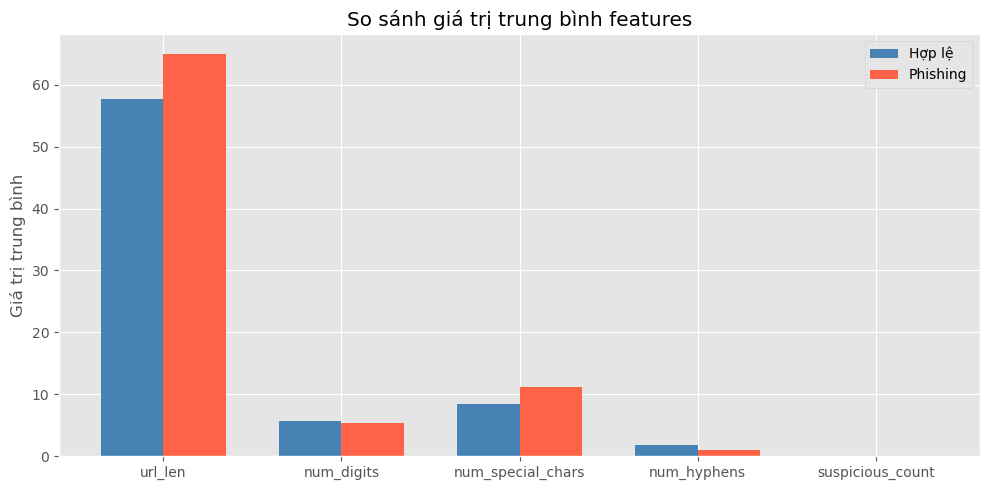

In [51]:
# =========================================================
# 18. SO SÁNH GIÁ TRỊ TRUNG BÌNH FEATURES
# =========================================================

selected_features = [
    'url_len',
    'num_digits',
    'num_special_chars',
    'num_hyphens',
    'suspicious_count'
]

legit_means = [
    feat_df[feat_df.label == 0][f].mean()
    for f in selected_features
]

phishing_means = [
    feat_df[feat_df.label == 1][f].mean()
    for f in selected_features
]

x = np.arange(len(selected_features))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width/2,
    legit_means,
    width,
    label='Hợp lệ',
    color='steelblue'
)

ax.bar(
    x + width/2,
    phishing_means,
    width,
    label='Phishing',
    color='tomato'
)

ax.set_xticks(x)

ax.set_xticklabels(selected_features)

ax.set_ylabel('Giá trị trung bình')

ax.set_title('So sánh giá trị trung bình features')

ax.legend()

plt.tight_layout()
plt.show()

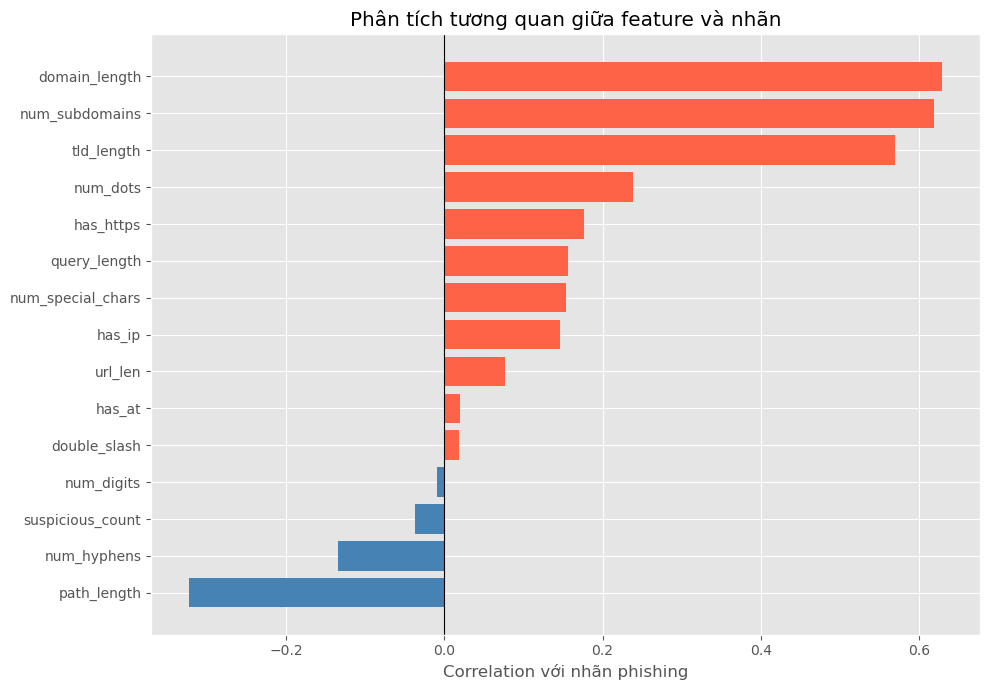

In [52]:
# =========================================================
# 19. PHÂN TÍCH TƯƠNG QUAN FEATURES
# =========================================================

corr = (
    feat_df.corr()['label']
    .drop('label')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    'tomato' if v > 0 else 'steelblue'
    for v in corr.values
]

ax.barh(
    corr.index,
    corr.values,
    color=colors
)

ax.set_xlabel('Correlation với nhãn phishing')

ax.set_title(
    'Phân tích tương quan giữa feature và nhãn'
)

ax.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.tight_layout()
plt.show()

In [53]:
# =========================================================
# 20. TOP FEATURES QUAN TRỌNG
# =========================================================

print("="*60)
print("FEATURE TƯƠNG QUAN DƯƠNG MẠNH NHẤT")
print("="*60)

print(corr.sort_values(ascending=False).head())

print()

print("="*60)
print("FEATURE TƯƠNG QUAN ÂM MẠNH NHẤT")
print("="*60)

print(corr.sort_values().head())

FEATURE TƯƠNG QUAN DƯƠNG MẠNH NHẤT
domain_length     0.629146
num_subdomains    0.618942
tld_length        0.568996
num_dots          0.238849
has_https         0.176432
Name: label, dtype: float64

FEATURE TƯƠNG QUAN ÂM MẠNH NHẤT
path_length        -0.322749
num_hyphens        -0.134250
suspicious_count   -0.037452
num_digits         -0.009526
double_slash        0.018392
Name: label, dtype: float64


In [61]:
# =========================================================
# CHUẨN HÓA URL CHO BiLSTM
# =========================================================

def clean_url(url):

    url = str(url).lower()

    url = url.replace("http://", "")
    url = url.replace("https://", "")
    url = url.replace("www.", "")

    return url


df['clean_url'] = df['url'].apply(clean_url)

display(
    df[['url', 'clean_url']].head()
)

,url,clean_url
0,br-icloud.com.br,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,bopsecrets.org/rexroth/cr/1.htm
3,http://www.garage-pirenne.be/index.php?option=...,garage-pirenne.be/index.php?option=com_content...
4,http://adventure-nicaragua.net/index.php?optio...,adventure-nicaragua.net/index.php?option=com_m...


In [65]:
from pathlib import Path


processed_dir = Path("../data_src_notebooks/processed")

# Chuẩn bị dataframe
processed_df = df[['clean_url', 'label']].copy()

# Lưu file
processed_df.to_csv(processed_dir / "processed_urls.csv", index=False)

print("✅ Lưu thành công vào thư mục processed!")
print("📍 Đường dẫn:", processed_dir / "processed_urls.csv")
print("Số dòng dữ liệu:", len(processed_df))

✅ Lưu thành công vào thư mục processed!
📍 Đường dẫn: ..\data_src_notebooks\processed\processed_urls.csv
Số dòng dữ liệu: 651191


In [67]:
# =========================================================
# IMPORT THƯ VIỆN CHO XGBOOST FEATURES
# =========================================================

import re
import numpy as np

from urllib.parse import urlparse

In [72]:
# =========================================================
# DANH SÁCH HANDCRAFTED FEATURES
# =========================================================

FEATURE_NAMES = [
    'url_len',
    'domain_length',
    'num_digits',
    'num_special_chars',
    'num_hyphens',
    'num_dots',
    'num_subdomains',
    'has_https',
    'has_ip',
    'suspicious_count',
    'has_at',
    'double_slash',
    'tld_length',
    'path_length',
    'query_length'
]
# =========================================================
# TỪ KHÓA ĐÁNG NGỜ
# =========================================================

suspicious_words = [
    'login',
    'verify',
    'secure',
    'account',
    'update',
    'banking',
    'confirm',
    'paypal',
    'password'
]


In [73]:
# =========================================================
# HÀM TRÍCH XUẤT FEATURES
# =========================================================

def extract_features(url):

    parsed = urlparse(url)

    features = []

    # 1. Độ dài URL
    features.append(len(url))

    # 2. Độ dài domain
    features.append(len(parsed.netloc))

    # 3. Số lượng chữ số
    features.append(
        sum(c.isdigit() for c in url)
    )

    # 4. Số ký tự đặc biệt
    features.append(
        len(re.findall(r'[^a-zA-Z0-9]', url))
    )

    # 5. Số dấu gạch ngang
    features.append(url.count('-'))

    # 6. Số dấu chấm
    features.append(url.count('.'))

    # 7. Số subdomain
    features.append(parsed.netloc.count('.'))

    # 8. Có HTTPS
    features.append(
        1 if parsed.scheme == 'https' else 0
    )

    # 9. Có IP address
    features.append(
        1 if re.match(
            r'^\d+\.\d+\.\d+\.\d+$',
            parsed.netloc
        ) else 0
    )

    # 10. suspicious words
    features.append(
        sum(word in url.lower()
            for word in suspicious_words)
    )

    # 11. Có ký tự @
    features.append(
        1 if '@' in url else 0
    )

    # 12. Có // bất thường
    features.append(
        1 if '//' in url[8:] else 0
    )

    # 13. Độ dài TLD
    tld = (
        parsed.netloc.split('.')[-1]
        if '.' in parsed.netloc
        else ''
    )

    features.append(len(tld))

    # 14. Độ dài path
    features.append(len(parsed.path))

    # 15. Độ dài query
    features.append(len(parsed.query))

    return features

In [74]:
# =========================================================
# TRÍCH XUẤT FEATURES HÀNG LOẠT
# =========================================================

def extract_batch(urls):

    return np.array([
        extract_features(url)
        for url in urls
    ])

In [75]:
# =========================================================
# TẠO FEATURE DATASET CHO XGBOOST
# =========================================================

print("Đang trích xuất handcrafted features...")

X_feat = extract_batch(
    df['clean_url'].tolist()
)

feat_df = pd.DataFrame(
    X_feat,
    columns=FEATURE_NAMES
)

feat_df['label'] = df['label'].values

display(feat_df.head())

Đang trích xuất handcrafted features...


,url_len,domain_length,num_digits,num_special_chars,num_hyphens,num_dots,num_subdomains,has_https,has_ip,suspicious_count,has_at,double_slash,tld_length,path_length,query_length,label
0,16,0,0,3,1,2,0,0,0,0,0,0,0,16,0,1
1,35,0,1,5,0,2,0,0,0,0,0,0,0,35,0,0
2,31,0,1,5,0,2,0,0,0,0,0,0,0,31,0,0
3,77,0,7,14,1,2,0,0,0,0,0,0,0,27,49,1
4,228,0,22,11,1,2,0,0,0,0,0,0,0,33,194,1


In [77]:
# =========================================================
# LƯU FEATURE DATASET
# =========================================================

feat_df.to_csv(
    "../data_src_notebooks/processed/feature_dataset.csv",
    index=False
)

print("Đã lưu feature_dataset.csv")

Đã lưu feature_dataset.csv
